## DataSet and DataPreprocessing

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch 
import torch.nn as nn 
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from sklearn.metrics import r2_score

In [28]:
df = pd.read_csv("X:\\VScode\\Artificial_intelligence_n_Machine_learning\\Deep_Learning\\CSV\\powerplant_data.csv")

In [29]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [30]:
df.shape

(9568, 5)

In [31]:
df.isna().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [33]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
# A tensor is a multidimensional array used to store 
# and process data, especially in machine learning.

# 1D - Scaler
# 2D - vector
# 3D - tensor
# 4D - tensor

# In our data there are 4 values so there will be 4 input features

In [37]:
# Converting data into tensor 
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

In [38]:
# Converting data into tensor 
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [39]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [40]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
)

## ANN - Artificial Neural Network

In [41]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            
            # 2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # Output Layer
            nn.Linear(6,1),
    )

    def forward(self, x):
        return self.model(x);

In [42]:
# device = torch.device("cuda")

Model = ANN()
# Loss, Optimizer

crietrion = nn.MSELoss()
optimizer = optim.Adam(Model.parameters())

In [43]:
# Train the ANN
epochs = 100
train_loss = []
val_losses = []
best_val_loss = float('inf')
# xb = xb.to(device)
# yb = yb.to(device)

# outputs = Model(xb)
for epoch in range(epochs):
    Model.train()
    runningLoss = 0.0  # total training loss for 1 epoch

    for xb, yb in train_loader:  # xb = feature of 1 batch / yb = label of 1 batch
        optimizer.zero_grad()
        outputs = Model(xb)  # predicted OP - Forward Prop
        loss = crietrion(outputs, yb)  # compute loss
        loss.backward()  # back prop - compute gradients
        optimizer.step()  # params update

        runningLoss += loss.item()

    epoch_train_loss = runningLoss / len(train_loader)
    train_loss.append(epoch_train_loss)

    # Validation Losses
    Model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = Model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} -> train loss = {epoch_train_loss} & Val loss = {epoch_val_loss}")
# Saving best ANN Model into {best_model.pt} 
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(Model.state_dict(), "Best_model.pt")

epoch 1/100 -> train loss = 206517.78971354166 & Val loss = 205775.23645833333
epoch 2/100 -> train loss = 204493.64127604166 & Val loss = 202123.31276041668
epoch 3/100 -> train loss = 197123.81608072916 & Val loss = 188662.31979166667
epoch 4/100 -> train loss = 173737.07389322916 & Val loss = 155974.5984375
epoch 5/100 -> train loss = 134296.68714192708 & Val loss = 111943.551171875
epoch 6/100 -> train loss = 89641.85618489583 & Val loss = 68645.12721354167
epoch 7/100 -> train loss = 51262.068090820314 & Val loss = 37870.89163411458
epoch 8/100 -> train loss = 30247.115572102866 & Val loss = 25097.541178385418
epoch 9/100 -> train loss = 22350.38428141276 & Val loss = 20217.64376627604
epoch 10/100 -> train loss = 18742.710009765626 & Val loss = 17093.415869140626
epoch 11/100 -> train loss = 15737.30029703776 & Val loss = 14028.763248697916
epoch 12/100 -> train loss = 12781.444952392578 & Val loss = 11401.656127929688
epoch 13/100 -> train loss = 10478.347115071614 & Val loss = 

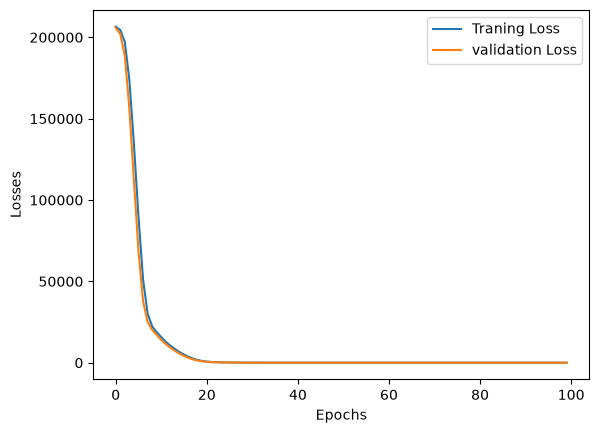

In [45]:
loss_df = pd.DataFrame({
    "training_loss":train_loss,
    "Validation_loss":val_losses
})

plt.plot(loss_df["training_loss"], label="Traning Loss")
plt.plot(loss_df["Validation_loss"], label="validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [25]:
Model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [53]:
# Evaluate our Model

Model.eval()
with torch.no_grad():
    train_predict = Model(X_train_tensor)
    test_predict = Model(X_test_tensor)

    train_mse_loss = crietrion(train_predict, y_train_tensor)
    test_mse_loss = crietrion(test_predict, y_test_tensor)


print(f"Traning MSE: {train_mse_loss:.3f}")
print(f"Test MSE: {test_mse_loss:.3f}")
print(f"R2 Score: {r2_score(y_test,test_predict):.3f}%")

Traning MSE: 21.400
Test MSE: 20.153
R2 Score: 0.930%


In [57]:
Pred_df = pd.DataFrame(test_predict.numpy(),columns=["Predicted Values"])
act_df = pd.DataFrame(y_test.values,columns=["Predicted Values"])


pd.concat([Pred_df, act_df], axis=1)

,Predicted Values,Predicted Values
0,437.007568,433.27
1,438.125549,438.16
2,460.828247,458.42
3,475.106445,480.82
4,436.428741,441.41
...,...,...
1909,451.963806,456.70
1910,433.188904,438.04
1911,468.040100,467.80
1912,432.600037,437.14
